# Klasifikasi: Prediksi Risiko Suicidal Ideation
## Mental Health Pelajar Indonesia - GSHS 2015

**Input:** `gshs2015_for_classification.csv`  

## Import & Load Data

In [1]:
# !pip install scikit-learn imbalanced-learn xgboost matplotlib seaborn pandas numpy

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import (train_test_split, StratifiedKFold,
                                      cross_val_score, RandomizedSearchCV)
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import (classification_report, confusion_matrix,
                              roc_auc_score, roc_curve, precision_recall_curve,
                              average_precision_score, ConfusionMatrixDisplay,
                              f1_score, recall_score, precision_score, accuracy_score)
from sklearn.inspection import permutation_importance
from imblearn.over_sampling import SMOTE, ADASYN
from imblearn.combine import SMOTETomek
import xgboost as xgb

plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.titlesize'] = 13
sns.set_style('whitegrid')
RS = 42
np.random.seed(RS)

In [2]:
df = pd.read_csv('gshs2015_for_classification.csv')
df = df.drop(columns=['mh_risk_score', 'bmi_encoded', 'jenjang_bin', 'jumlah_teman',
                       'perkelahian_fisik', 'flag_aktif_fisik_bin', 'behavior_risk_score', 'kelas'],
             errors='ignore')

TARGET    = 'target'
feat_cols = [c for c in df.columns if c != TARGET]
X_raw     = df[feat_cols].values
y         = df[TARGET].values

print(f'Dataset   : {df.shape[0]:,} baris × {df.shape[1]} kolom')
print(f'Fitur     : {len(feat_cols)}')
print(f'\nFitur:')
for i, c in enumerate(feat_cols, 1):
    print(f'  {i:2}. {c}')

vc = pd.Series(y).value_counts().sort_index()
print(f'\nDistribusi target:')
print(f'  0 (Tidak suicidal): {vc[0]:,} ({vc[0]/len(y)*100:.2f}%)')
print(f'  1 (Suicidal)       : {vc[1]:,} ({vc[1]/len(y)*100:.2f}%)')
print(f'  Rasio imbalance    : {vc[0]/vc[1]:.1f}:1')

Dataset   : 10,977 baris × 10 kolom
Fitur     : 9

Fitur:
   1. usia
   2. gender_bin
   3. kesepian
   4. khawatir_insomnia
   5. hari_dibully
   6. diserang_fisik
   7. flag_perokok_bin
   8. flag_alkohol_bin
   9. flag_narkoba_bin

Distribusi target:
  0 (Tidak suicidal): 10,373 (94.50%)
  1 (Suicidal)       : 604 (5.50%)
  Rasio imbalance    : 17.2:1


## Eksplorasi & Class Imbalance

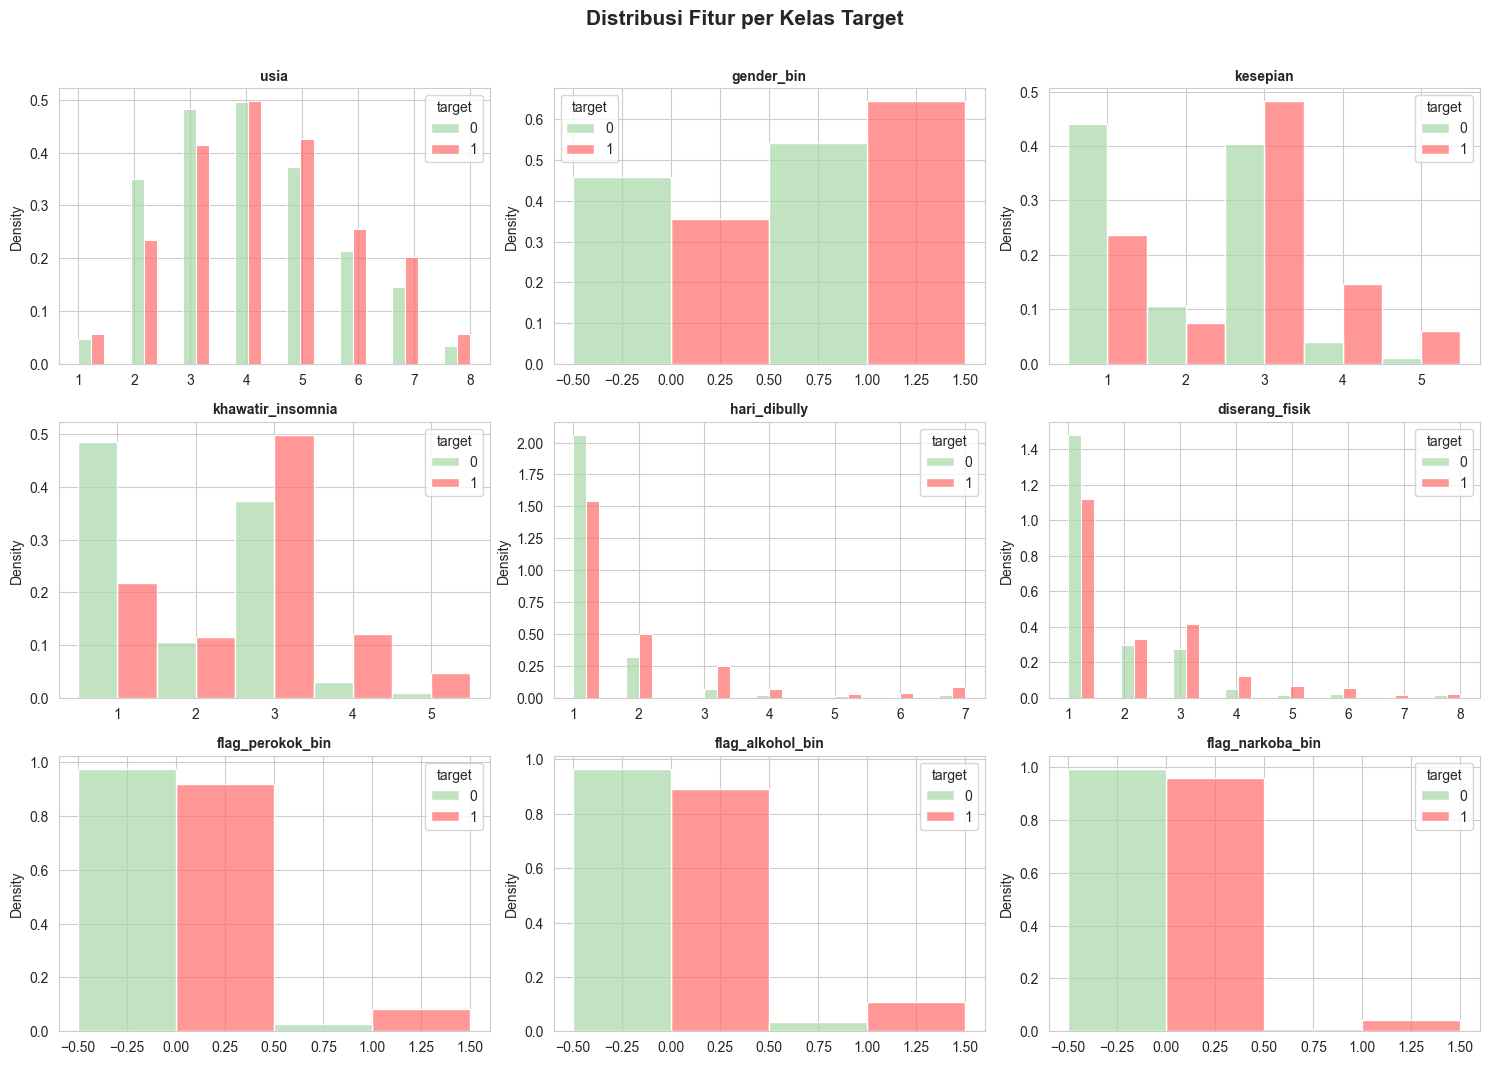

In [3]:
# Visualisasi distribusi fitur per kelas
n_feats = len(feat_cols)
n_cols = 3
n_rows = (n_feats + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, n_rows * 3.5))
axes = axes.flatten()
colors_cls = {0: '#A8D8A8', 1: '#FF6B6B'}

for i, col in enumerate(feat_cols):
    ax = axes[i]
    is_cat = df[col].nunique() <= 6
    sns.histplot(data=df, x=col, hue=TARGET, ax=ax,
                 palette=colors_cls, stat='density', common_norm=False,
                 discrete=is_cat, multiple='dodge', alpha=0.7,
                 bins=15 if not is_cat else 'auto')
    ax.set_title(col, fontsize=10, fontweight='bold')
    ax.set_xlabel('')

for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Distribusi Fitur per Kelas Target', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

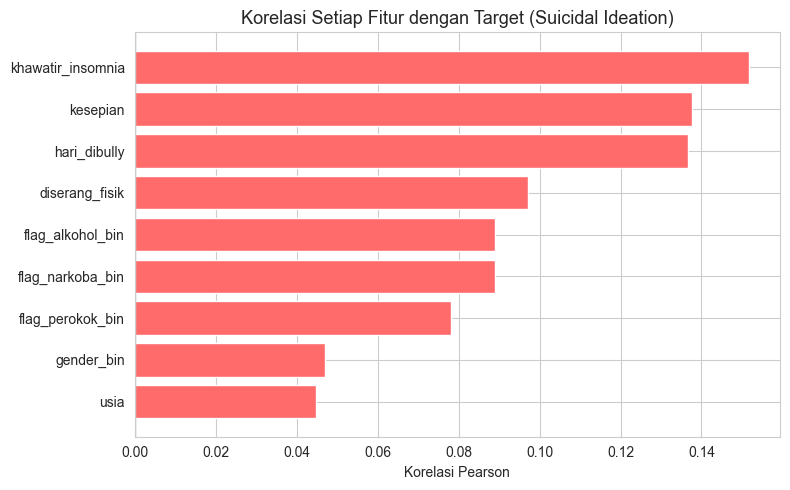

Top 5 fitur paling berkorelasi positif:
flag_alkohol_bin     0.0891
diserang_fisik       0.0971
hari_dibully         0.1367
kesepian             0.1377
khawatir_insomnia    0.1518


In [4]:
# Korelasi dengan target
corr_target = df.corr()[TARGET].drop(TARGET).sort_values()
fig, ax = plt.subplots(figsize=(8, max(5, len(feat_cols)*0.5)))
colors_bar = ['#FF6B6B' if v > 0 else '#A8D8A8' for v in corr_target]
ax.barh(corr_target.index, corr_target.values, color=colors_bar, edgecolor='white')
ax.axvline(0, color='black', lw=0.8)
ax.set_title('Korelasi Setiap Fitur dengan Target (Suicidal Ideation)')
ax.set_xlabel('Korelasi Pearson')
plt.tight_layout()
plt.show()

print('Top 5 fitur paling berkorelasi positif:')
print(corr_target.tail(5).round(4).to_string())

## Preprocessing: Split + SMOTE + ADASYN

### Perbandingan teknik oversampling:
| Teknik | Cara Kerja | Cocok Untuk |
|---|---|---|
| **SMOTE** | Interpolasi antara sampel minoritas | Baseline yang bagus |
| **ADASYN** | Fokus pada sampel yang sulit diklasifikasi | Batas keputusan yang rumit |
| **SMOTETomek** | SMOTE + hapus noise dari mayoritas | Dataset dengan overlap kelas |

In [5]:
# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X_raw, y, test_size=0.2, random_state=RS, stratify=y
)

print(f'Train : {len(X_train):,} ({len(X_train)/len(y)*100:.0f}%)')
print(f'  Kelas 0: {(y_train==0).sum():,}  Kelas 1: {(y_train==1).sum():,}')
print(f'Test  : {len(X_test):,} ({len(X_test)/len(y)*100:.0f}%)')
print(f'  Kelas 0: {(y_test==0).sum():,}  Kelas 1: {(y_test==1).sum():,}')

Train : 8,781 (80%)
  Kelas 0: 8,298  Kelas 1: 483
Test  : 2,196 (20%)
  Kelas 0: 2,075  Kelas 1: 121


In [6]:
# Buat 3 versi training set dengan teknik berbeda
print('Menerapkan teknik oversampling...')

# SMOTE
smote = SMOTE(random_state=RS)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)
print(f'SMOTE      = 0: {(y_train_sm==0).sum()}  1: {(y_train_sm==1).sum()}')

# ADASYN
adasyn = ADASYN(random_state=RS)
X_train_ad, y_train_ad = adasyn.fit_resample(X_train, y_train)
print(f'ADASYN     = 0: {(y_train_ad==0).sum()}  1: {(y_train_ad==1).sum()}')

# SMOTETomek
smt = SMOTETomek(random_state=RS)
X_train_smt, y_train_smt = smt.fit_resample(X_train, y_train)
print(f'SMOTETomek = 0: {(y_train_smt==0).sum()}  1: {(y_train_smt==1).sum()}')

# Default: SMOTE
X_tr, y_tr = X_train_sm, y_train_sm
print('\nDefault training set: SMOTE')

# Cross-validation setup
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RS)

Menerapkan teknik oversampling...
SMOTE      = 0: 8298  1: 8298
ADASYN     = 0: 8298  1: 8390
SMOTETomek = 0: 8290  1: 8290

Default training set: SMOTE


In [7]:
def evaluate_model(name, model, X_tr, y_tr, X_te, y_te, cv_obj, threshold=0.5):
    """Fit, evaluasi dengan threshold custom, print report + confusion matrix + ROC."""
    model.fit(X_tr, y_tr)
    
    if hasattr(model, 'predict_proba'):
        y_proba = model.predict_proba(X_te)[:, 1]
        y_pred  = (y_proba >= threshold).astype(int)
    else:
        y_pred  = model.predict(X_te)
        y_proba = None

    print(f'\n{"="*60}')
    print(f'  {name}  (threshold={threshold:.2f})')
    print(f'{"="*60}')
    print(classification_report(y_te, y_pred,
          target_names=['Tidak(0)', 'Suicidal(1)'], digits=4))

    # CV Recall (ini dia prio kita)
    cv_rec = cross_val_score(model, X_raw, y, cv=cv_obj,
                              scoring='recall', n_jobs=-1)
    cv_f1  = cross_val_score(model, X_raw, y, cv=cv_obj,
                              scoring='f1', n_jobs=-1)
    print(f'CV Recall (5-fold): {cv_rec.mean():.4f} ± {cv_rec.std():.4f}')
    print(f'CV F1    (5-fold): {cv_f1.mean():.4f} ± {cv_f1.std():.4f}')

    auc, ap = None, None
    if y_proba is not None:
        auc = roc_auc_score(y_te, y_proba)
        ap  = average_precision_score(y_te, y_proba)
        print(f'ROC-AUC : {auc:.4f}')
        print(f'Avg Prec: {ap:.4f}')

    # Confusion matrix + ROC curve
    ncols = 2 if y_proba is not None else 1
    fig, axes = plt.subplots(1, ncols, figsize=(12, 4))
    if not isinstance(axes, np.ndarray): axes = [axes]
    
    ConfusionMatrixDisplay.from_predictions(
        y_te, y_pred, display_labels=['Tidak', 'Suicidal'],
        cmap='Blues', ax=axes[0])
    axes[0].set_title(f'Confusion Matrix - {name}')

    if y_proba is not None:
        fpr, tpr, _ = roc_curve(y_te, y_proba)
        axes[1].plot(fpr, tpr, lw=2, color='#E74C3C', label=f'AUC={auc:.4f}')
        axes[1].plot([0,1],[0,1], 'k--', lw=1)
        axes[1].set_title(f'ROC Curve — {name}')
        axes[1].set_xlabel('False Positive Rate')
        axes[1].set_ylabel('True Positive Rate')
        axes[1].legend()
    plt.tight_layout()
    plt.show()

    return model, {'auc': auc, 'ap': ap, 'y_pred': y_pred, 'y_proba': y_proba,
                   'threshold': threshold}


def find_optimal_threshold(y_true, y_proba, strategy='f1', min_recall=0.70):
    """
    Cari threshold optimal.
    strategy='recall'  threshold yang memaksimalkan recall dengan precision >= min_precision
    strategy='f1'      threshold yang memaksimalkan F1
    strategy='recall_constrained'  maksimalkan recall, F1 >= min_f1_threshold
    """
    prec, rec, thresholds = precision_recall_curve(y_true, y_proba)
    f1_scores = 2 * prec * rec / (prec + rec + 1e-9)
    
    if strategy == 'f1':
        best_idx = np.argmax(f1_scores[:-1])
        best_t   = thresholds[best_idx]
        label    = 'Max F1'
    elif strategy == 'recall_constrained':
        # Cari threshold dengan recall >= min_recall, lalu pilih yang F1 terbaik
        mask = rec[:-1] >= min_recall
        if mask.any():
            best_idx = np.argmax(f1_scores[:-1][mask])
            best_t   = thresholds[mask][best_idx]
        else:
            best_t = thresholds[np.argmax(rec[:-1])]
        label = f'Recall≥{min_recall}, Best F1'
    else:  # recall
        best_t = thresholds[np.argmax(rec[:-1])]
        label  = 'Max Recall'
    
    return best_t, label

## Decision Tree (Baseline)

Depth terbaik: 11  (CV Recall=0.8624)


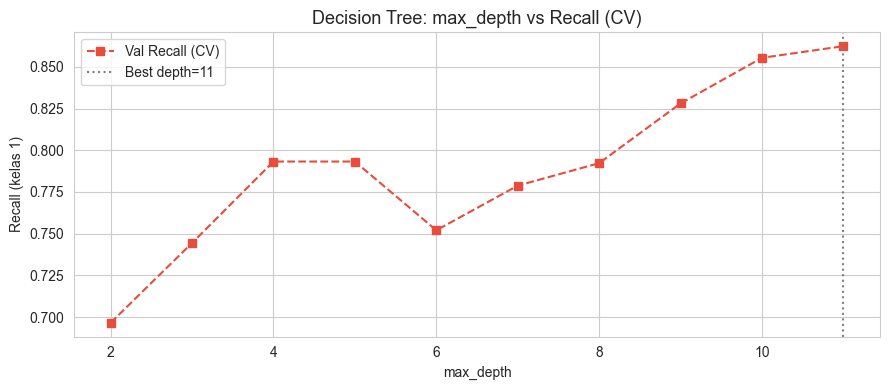

In [8]:
# Tuning max_depth
depths = range(2, 12)
dt_f1_val = []
for d in depths:
    dt_tmp = DecisionTreeClassifier(max_depth=d, class_weight='balanced', random_state=RS)
    f1_cv  = cross_val_score(dt_tmp, X_tr, y_tr, cv=cv, scoring='recall', n_jobs=-1)
    dt_f1_val.append(f1_cv.mean())

best_depth = list(depths)[np.argmax(dt_f1_val)]
print(f'Depth terbaik: {best_depth}  (CV Recall={max(dt_f1_val):.4f})')

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(depths, dt_f1_val, 's--', color='#E74C3C', label='Val Recall (CV)')
ax.axvline(best_depth, color='gray', ls=':', lw=1.5, label=f'Best depth={best_depth}')
ax.set_title('Decision Tree: max_depth vs Recall (CV)')
ax.set_xlabel('max_depth'); ax.set_ylabel('Recall (kelas 1)'); ax.legend()
plt.tight_layout(); plt.show()


  Decision Tree  (threshold=0.50)
              precision    recall  f1-score   support

    Tidak(0)     0.9545    0.8400    0.8936      2075
 Suicidal(1)     0.1027    0.3140    0.1548       121

    accuracy                         0.8110      2196
   macro avg     0.5286    0.5770    0.5242      2196
weighted avg     0.9076    0.8110    0.8529      2196

CV Recall (5-fold): 0.4852 ± 0.0510
CV F1    (5-fold): 0.1675 ± 0.0133
ROC-AUC : 0.6044
Avg Prec: 0.0967


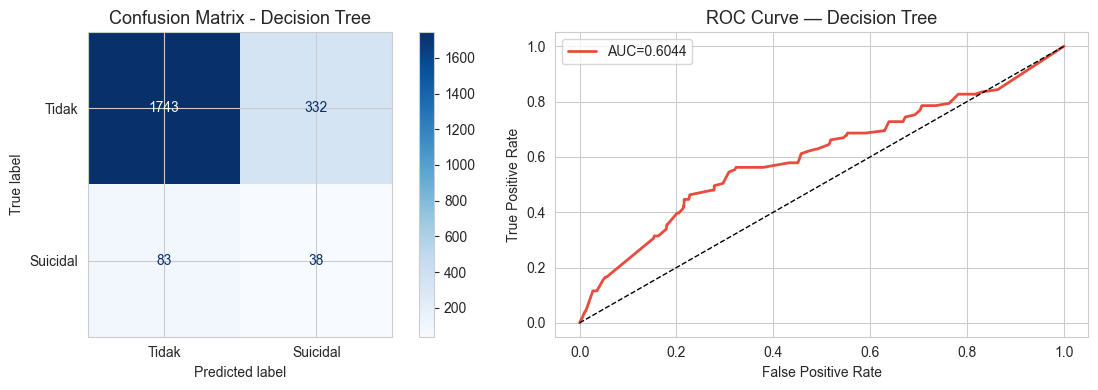

In [9]:
dt_model = DecisionTreeClassifier(
    max_depth=best_depth, class_weight='balanced',
    criterion='gini', random_state=RS
)
dt_model, dt_metrics = evaluate_model(
    'Decision Tree', dt_model, X_tr, y_tr, X_test, y_test, cv
)

## Random Forest + Hyperparameter Tuning (RandomizedSearchCV)

In [10]:
from scipy.stats import randint

print('RandomizedSearchCV untuk Random Forest (scoring=recall)...')
rf_param_dist = {
    'n_estimators'      : randint(100, 400),
    'max_depth'         : [None, 5, 10, 15, 20],
    'min_samples_split' : randint(2, 10),
    'min_samples_leaf'  : randint(1, 5),
    'max_features'      : ['sqrt', 'log2', None],
}

rf_base = RandomForestClassifier(class_weight='balanced', random_state=RS, n_jobs=-1)
rf_search = RandomizedSearchCV(
    rf_base, rf_param_dist,
    n_iter=30,               # 30 kombinasi random
    scoring='recall',        # optimasi Recall kelas 1
    cv=cv, n_jobs=-1,
    random_state=RS, verbose=1
)
rf_search.fit(X_tr, y_tr)

print(f'\nBest params: {rf_search.best_params_}')
print(f'Best CV Recall: {rf_search.best_score_:.4f}')

RandomizedSearchCV untuk Random Forest (scoring=recall)...
Fitting 5 folds for each of 30 candidates, totalling 150 fits

Best params: {'max_depth': 20, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 4, 'n_estimators': 158}
Best CV Recall: 0.9094



  Random Forest (tuned)  (threshold=0.50)
              precision    recall  f1-score   support

    Tidak(0)     0.9513    0.9036    0.9268      2075
 Suicidal(1)     0.1111    0.2066    0.1445       121

    accuracy                         0.8652      2196
   macro avg     0.5312    0.5551    0.5357      2196
weighted avg     0.9050    0.8652    0.8837      2196

CV Recall (5-fold): 0.2302 ± 0.0499
CV F1    (5-fold): 0.1268 ± 0.0254
ROC-AUC : 0.6629
Avg Prec: 0.1093


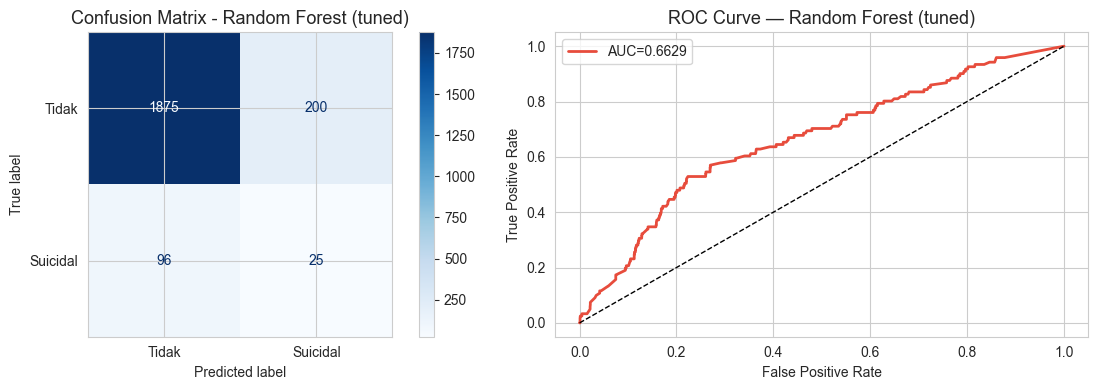

In [11]:
rf_model = rf_search.best_estimator_
rf_model, rf_metrics = evaluate_model(
    'Random Forest (tuned)', rf_model, X_tr, y_tr, X_test, y_test, cv
)

## Support Vector Machine (SVM)

Fitting SVM (kernel=rbf, class_weight=balanced)...
  Subsample: 8000 dari 16,596

  SVM (RBF)  (threshold=0.50)
              precision    recall  f1-score   support

    Tidak(0)     0.9741    0.7080    0.8200      2075
 Suicidal(1)     0.1192    0.6777    0.2027       121

    accuracy                         0.7063      2196
   macro avg     0.5467    0.6928    0.5114      2196
weighted avg     0.9270    0.7063    0.7860      2196

CV Recall (5-fold): 0.6407 ± 0.0379
CV F1    (5-fold): 0.2116 ± 0.0065
ROC-AUC : 0.7271
Avg Prec: 0.1782


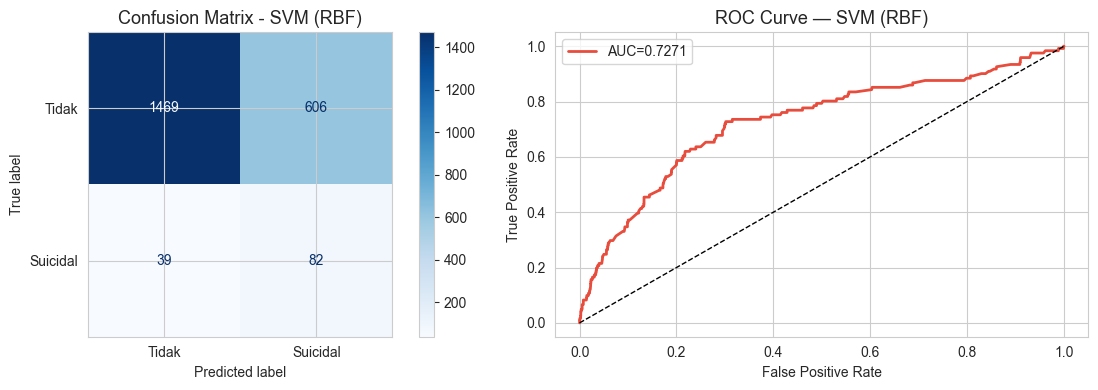

In [12]:
print('Fitting SVM (kernel=rbf, class_weight=balanced)...')

# Subsample untuk speed
if len(X_tr) > 8000:
    idx_sub = np.random.choice(len(X_tr), 8000, replace=False)
    X_tr_svm, y_tr_svm = X_tr[idx_sub], y_tr[idx_sub]
    print(f'  Subsample: 8000 dari {len(X_tr):,}')
else:
    X_tr_svm, y_tr_svm = X_tr, y_tr

svm_model = SVC(kernel='rbf', C=1.0, gamma='scale',
                class_weight='balanced', probability=True, random_state=RS)
svm_model, svm_metrics = evaluate_model(
    'SVM (RBF)', svm_model, X_tr_svm, y_tr_svm, X_test, y_test, cv
)

## XGBoost + Hyperparameter Tuning

- Parameter `scale_pos_weight` untuk menangani imbalance secara langsung
- Gradient boosting: bias rendah
-  Regularisasi built-in (L1/L2) overfitting terkontrol (semoga)

In [13]:
# Hitung scale_pos_weight = jumlah kelas negatif / jumlah kelas positif
neg_count = (y_train == 0).sum()
pos_count = (y_train == 1).sum()
spw = neg_count / pos_count
print(f'scale_pos_weight = {neg_count}/{pos_count} = {spw:.2f}')
print(f'Artinya: setiap sampel kelas 1 diberi bobot {spw:.2f}x lebih besar')

scale_pos_weight = 8298/483 = 17.18
Artinya: setiap sampel kelas 1 diberi bobot 17.18x lebih besar


In [14]:
from scipy.stats import uniform

print('RandomizedSearchCV untuk XGBoost (scoring=recall)...')
print('Ini mungkin butuh 2-5 menit...\n')

xgb_param_dist = {
    'n_estimators'       : randint(100, 500),
    'max_depth'          : randint(3, 9),
    'learning_rate'      : uniform(0.01, 0.29),   # 0.01 - 0.30
    'subsample'          : uniform(0.6, 0.4),     # 0.6 - 1.0
    'colsample_bytree'   : uniform(0.6, 0.4),     # 0.6 - 1.0
    'min_child_weight'   : randint(1, 6),
    'gamma'              : uniform(0, 0.5),
    'reg_alpha'          : uniform(0, 1),          # L1
    'reg_lambda'         : uniform(0.5, 1.5),      # L2
    'scale_pos_weight'   : [spw, spw*1.5, spw*2],  # beri bobot lebih pada kelas positif
}

xgb_base = xgb.XGBClassifier(
    eval_metric='logloss',
    use_label_encoder=False,
    random_state=RS,
    n_jobs=-1,
    verbosity=0
)

xgb_search = RandomizedSearchCV(
    xgb_base, xgb_param_dist,
    n_iter=30,
    scoring='recall',      # optimasi Recall kelas 1
    cv=cv, n_jobs=-1,
    random_state=RS, verbose=1
)
xgb_search.fit(X_train, y_train)

print(f'\nBest params XGBoost: {xgb_search.best_params_}')
print(f'Best CV Recall: {xgb_search.best_score_:.4f}')

RandomizedSearchCV untuk XGBoost (scoring=recall)...
Ini mungkin butuh 2-5 menit...

Fitting 5 folds for each of 30 candidates, totalling 150 fits

Best params XGBoost: {'colsample_bytree': np.float64(0.8534118843043579), 'gamma': np.float64(0.26788734203737924), 'learning_rate': np.float64(0.03618403331577841), 'max_depth': 3, 'min_child_weight': 1, 'n_estimators': 223, 'reg_alpha': np.float64(0.5081987767407187), 'reg_lambda': np.float64(1.5437192101863229), 'scale_pos_weight': np.float64(34.36024844720497), 'subsample': np.float64(0.8363571772752967)}
Best CV Recall: 0.8241



  XGBoost (tuned)  (threshold=0.50)
              precision    recall  f1-score   support

    Tidak(0)     0.9767    0.5060    0.6667      2075
 Suicidal(1)     0.0856    0.7934    0.1546       121

    accuracy                         0.5219      2196
   macro avg     0.5312    0.6497    0.4106      2196
weighted avg     0.9276    0.5219    0.6385      2196

CV Recall (5-fold): 0.8195 ± 0.0259
CV F1    (5-fold): 0.1554 ± 0.0060
ROC-AUC : 0.7491
Avg Prec: 0.2095


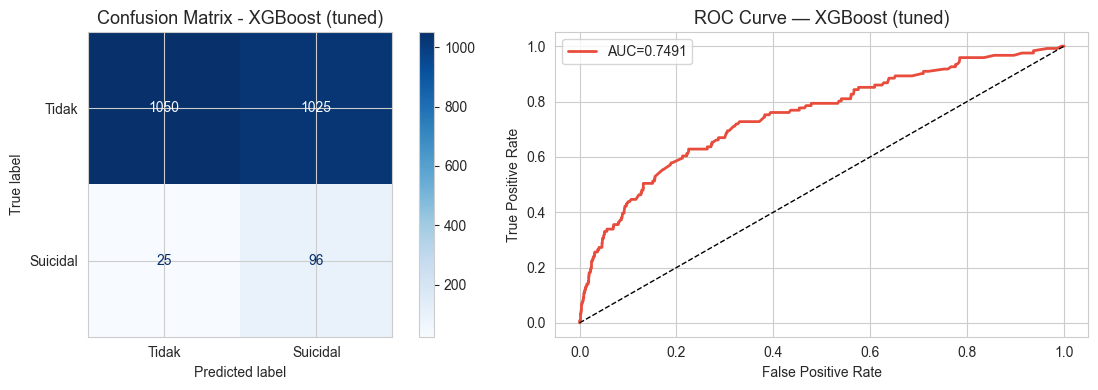

In [15]:
xgb_model = xgb_search.best_estimator_
xgb_model, xgb_metrics = evaluate_model(
    'XGBoost (tuned)', xgb_model,
    X_train, y_train,
    X_test, y_test, cv
)

XGBoost + SMOTE (untuk perbandingan)

  XGBoost + SMOTE  (threshold=0.50)
              precision    recall  f1-score   support

    Tidak(0)     0.9583    0.8752    0.9149      2075
 Suicidal(1)     0.1395    0.3471    0.1991       121

    accuracy                         0.8461      2196
   macro avg     0.5489    0.6111    0.5570      2196
weighted avg     0.9132    0.8461    0.8754      2196

CV Recall (5-fold): 0.0182 ± 0.0142
CV F1    (5-fold): 0.0347 ± 0.0271
ROC-AUC : 0.6971
Avg Prec: 0.1607


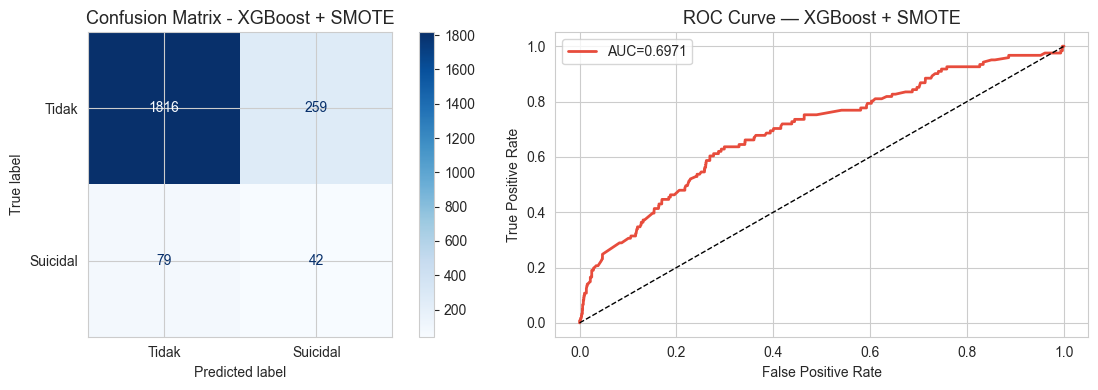

In [16]:
# Coba  XGBoost + SMOTE untuk perbandingan
print('XGBoost + SMOTE (untuk perbandingan)')
xgb_smote = xgb.XGBClassifier(
    **{k: v for k, v in xgb_search.best_params_.items() if k != 'scale_pos_weight'},
    eval_metric='logloss', use_label_encoder=False,
    random_state=RS, n_jobs=-1, verbosity=0
)
xgb_smote, xgb_smote_metrics = evaluate_model(
    'XGBoost + SMOTE', xgb_smote,
    X_tr, y_tr,   # dengan SMOTE
    X_test, y_test, cv
)

## Threshold Optimization 

Default threshold = 0.5 sering tidak optimal untuk data imbalance.  

=== Threshold Analysis: Random Forest ===


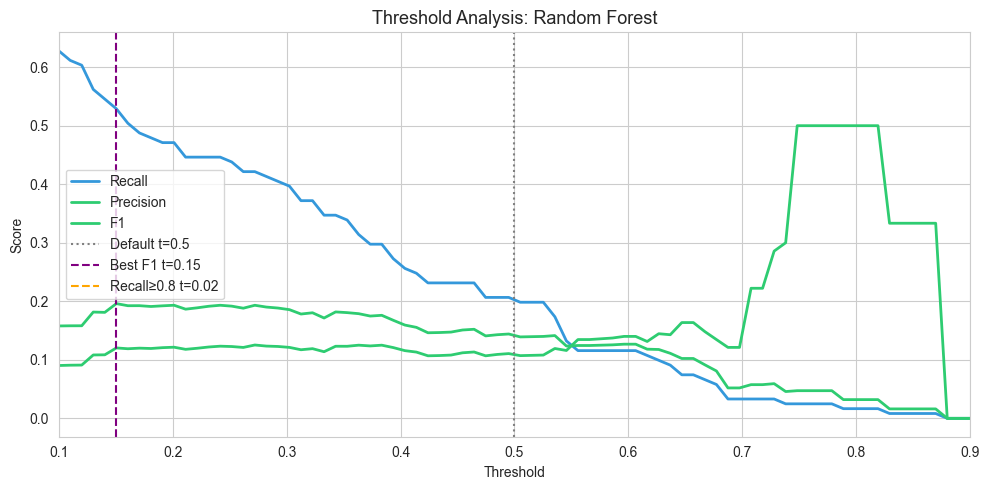

  Default (0.50): Recall=0.2066, F1=0.1441
  Best F1 (0.15): Recall=0.5289, F1=0.1960

=== Threshold Analysis: XGBoost ===


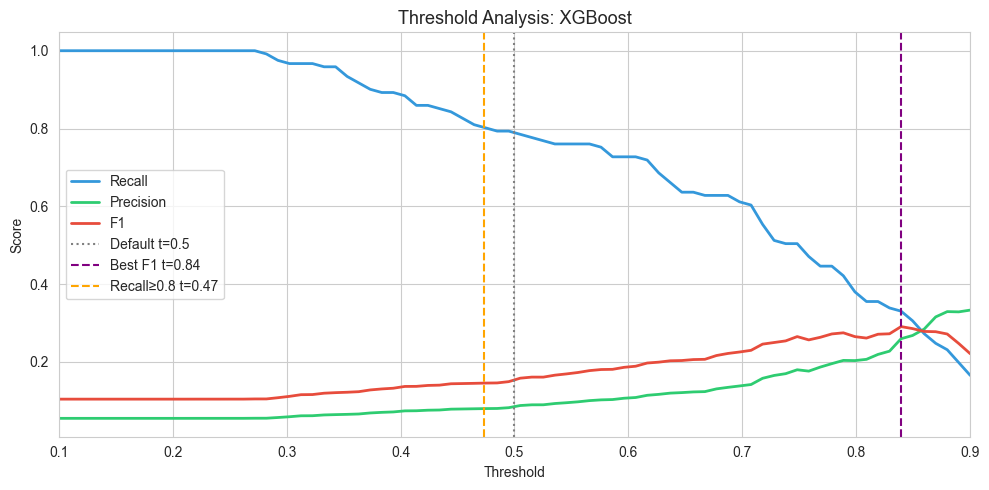

  Default (0.50): Recall=0.7934, F1=0.1494
  Best F1 (0.84): Recall=0.3306, F1=0.2909


In [17]:
def plot_threshold_analysis(name, y_true, y_proba, color='#E74C3C'):
    """Plot Precision, Recall, F1 vs threshold."""
    thresholds = np.linspace(0.1, 0.9, 80)
    precisions, recalls, f1s = [], [], []
    
    for t in thresholds:
        yp = (y_proba >= t).astype(int)
        precisions.append(precision_score(y_true, yp, zero_division=0))
        recalls.append(recall_score(y_true, yp, zero_division=0))
        f1s.append(f1_score(y_true, yp, zero_division=0))
    
    # Threshold optimal
    t_f1      = thresholds[np.argmax(f1s)]
    t_recall70, _ = find_optimal_threshold(y_true, y_proba, 'recall_constrained', 0.80)
    
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.plot(thresholds, recalls,    lw=2, color='#3498DB', label='Recall')
    ax.plot(thresholds, precisions, lw=2, color='#2ECC71', label='Precision')
    ax.plot(thresholds, f1s,        lw=2, color=color,     label='F1')
    ax.axvline(0.5,     color='gray', ls=':', lw=1.5, label='Default t=0.5')
    ax.axvline(t_f1,    color='purple', ls='--', lw=1.5, label=f'Best F1 t={t_f1:.2f}')
    ax.axvline(t_recall70, color='orange', ls='--', lw=1.5, label=f'Recall≥0.8 t={t_recall70:.2f}')
    ax.set_title(f'Threshold Analysis: {name}')
    ax.set_xlabel('Threshold')
    ax.set_ylabel('Score')
    ax.legend(loc='center left')
    ax.set_xlim(0.1, 0.9)
    plt.tight_layout()
    plt.show()
    
    print(f'  Default (0.50): Recall={recalls[thresholds.tolist().index(min(thresholds, key=lambda x: abs(x-0.5)))]:.4f}, '
          f'F1={f1s[thresholds.tolist().index(min(thresholds, key=lambda x: abs(x-0.5)))]:.4f}')
    idx_f1  = np.argmax(f1s)
    print(f'  Best F1 ({t_f1:.2f}): Recall={recalls[idx_f1]:.4f}, F1={f1s[idx_f1]:.4f}')
    
    return t_f1, t_recall70

print('=== Threshold Analysis: Random Forest ===')
rf_t_f1, rf_t_recall = plot_threshold_analysis(
    'Random Forest', y_test, rf_metrics['y_proba'], '#2ECC71')

print('\n=== Threshold Analysis: XGBoost ===')
xgb_t_f1, xgb_t_recall = plot_threshold_analysis(
    'XGBoost', y_test, xgb_metrics['y_proba'], '#E74C3C')

=== Random Forest dengan threshold optimal (Best F1) ===

  Random Forest (t=0.15)  (threshold=0.15)
              precision    recall  f1-score   support

    Tidak(0)     0.9657    0.7745    0.8596      2075
 Suicidal(1)     0.1203    0.5289    0.1960       121

    accuracy                         0.7609      2196
   macro avg     0.5430    0.6517    0.5278      2196
weighted avg     0.9192    0.7609    0.8230      2196

CV Recall (5-fold): 0.2302 ± 0.0499
CV F1    (5-fold): 0.1268 ± 0.0254
ROC-AUC : 0.6629
Avg Prec: 0.1093


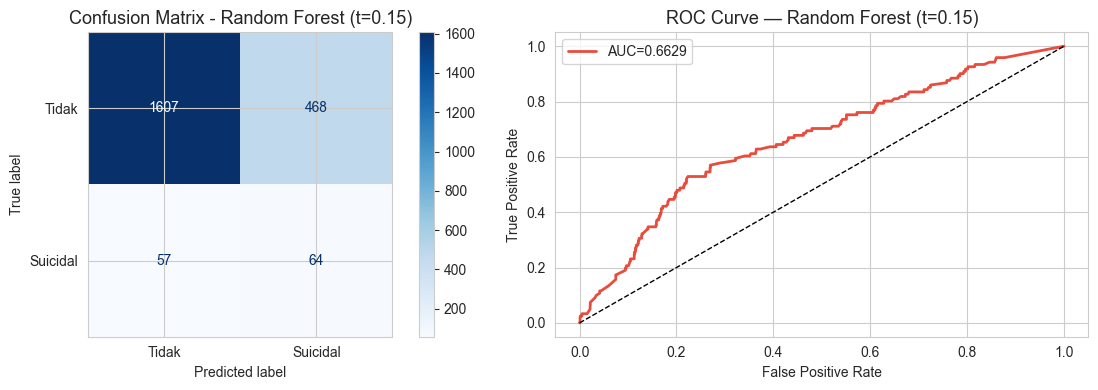

In [18]:
# Re-evaluasi model terbaik dengan threshold optimal
print('=== Random Forest dengan threshold optimal (Best F1) ===')
_, rf_tuned_metrics = evaluate_model(
    f'Random Forest (t={rf_t_f1:.2f})', rf_model,
    X_tr, y_tr, X_test, y_test, cv,
    threshold=rf_t_f1
)

=== XGBoost dengan threshold optimal (Best F1) ===

  XGBoost (t=0.84)  (threshold=0.84)
              precision    recall  f1-score   support

    Tidak(0)     0.9603    0.9451    0.9526      2075
 Suicidal(1)     0.2597    0.3306    0.2909       121

    accuracy                         0.9112      2196
   macro avg     0.6100    0.6378    0.6218      2196
weighted avg     0.9217    0.9112    0.9162      2196

CV Recall (5-fold): 0.8195 ± 0.0259
CV F1    (5-fold): 0.1554 ± 0.0060
ROC-AUC : 0.7491
Avg Prec: 0.2095


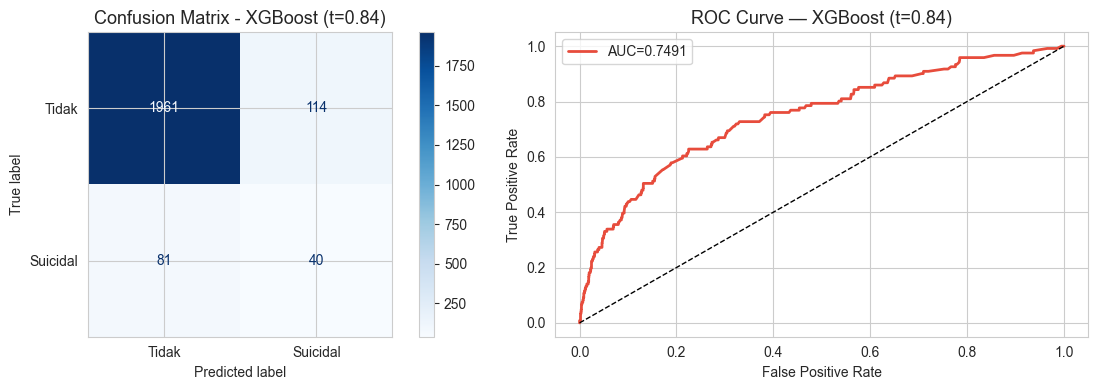

In [19]:
print('=== XGBoost dengan threshold optimal (Best F1) ===')
_, xgb_tuned_metrics = evaluate_model(
    f'XGBoost (t={xgb_t_f1:.2f})', xgb_model,
    X_train, y_train, X_test, y_test, cv,
    threshold=xgb_t_f1
)

=== XGBoost dengan threshold optimal (Recall≥0.80) ===

  XGBoost (Recall≥0.80, t=0.47)  (threshold=0.47)
              precision    recall  f1-score   support

    Tidak(0)     0.9765    0.4598    0.6252      2075
 Suicidal(1)     0.0804    0.8099    0.1463       121

    accuracy                         0.4791      2196
   macro avg     0.5284    0.6348    0.3857      2196
weighted avg     0.9271    0.4791    0.5988      2196

CV Recall (5-fold): 0.8195 ± 0.0259
CV F1    (5-fold): 0.1554 ± 0.0060
ROC-AUC : 0.7491
Avg Prec: 0.2095


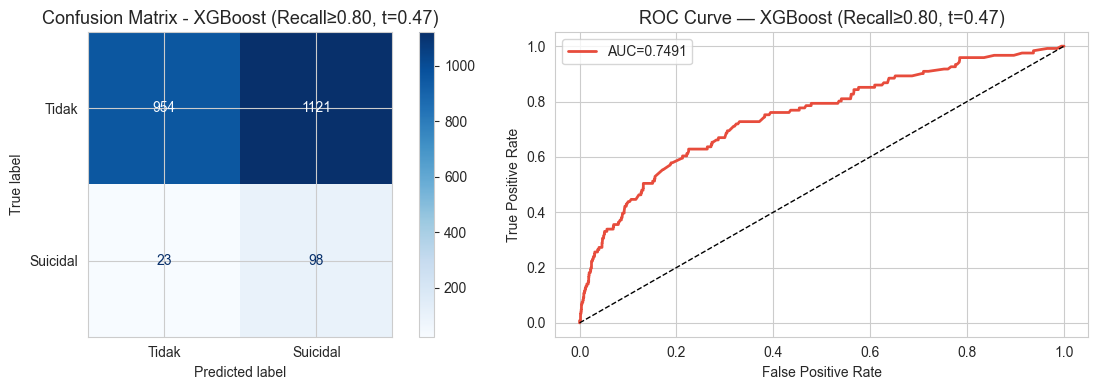

In [20]:
print('=== XGBoost dengan threshold optimal (Recall≥0.80) ===')
_, xgb_recall_metrics = evaluate_model(
    f'XGBoost (Recall≥0.80, t={xgb_t_recall:.2f})', xgb_model,
    X_train, y_train, X_test, y_test, cv,
    threshold=xgb_t_recall
)

## Perbandingan Model (Lengkap)

In [21]:
def model_row(name, y_true, y_pred, y_proba=None, threshold=0.5):
    return {
        'Model'        : name,
        'Threshold'    : threshold,
        'Accuracy'     : round(accuracy_score(y_true, y_pred), 4),
        'Precision(1)' : round(precision_score(y_true, y_pred, zero_division=0), 4),
        'Recall(1)'    : round(recall_score(y_true, y_pred, zero_division=0), 4),
        'F1(1)'        : round(f1_score(y_true, y_pred, zero_division=0), 4),
        'ROC-AUC'      : round(roc_auc_score(y_true, y_proba), 4) if y_proba is not None else '-',
    }

rows = [
    model_row('Decision Tree',                    y_test, dt_metrics['y_pred'],         dt_metrics['y_proba'],       0.5),
    model_row('Random Forest (tuned, t=0.50)',    y_test, rf_metrics['y_pred'],         rf_metrics['y_proba'],       0.5),
    model_row(f'Random Forest (tuned, t={rf_t_f1:.2f})', y_test, rf_tuned_metrics['y_pred'],   rf_tuned_metrics['y_proba'], rf_t_f1),
    model_row('SVM (RBF)',                        y_test, svm_metrics['y_pred'],        svm_metrics['y_proba'],      0.5),
    model_row('XGBoost (tuned, t=0.50)',          y_test, xgb_metrics['y_pred'],        xgb_metrics['y_proba'],      0.5),
    model_row(f'XGBoost (tuned, t={xgb_t_f1:.2f})',      y_test, xgb_tuned_metrics['y_pred'],  xgb_tuned_metrics['y_proba'], xgb_t_f1),
    model_row(f'XGBoost + SMOTE (t=0.50)',        y_test, xgb_smote_metrics['y_pred'], xgb_smote_metrics['y_proba'],0.5),
    model_row(f'XGBoost (Recall≥0.80, t={xgb_t_recall:.2f})', y_test, xgb_recall_metrics['y_pred'], xgb_recall_metrics['y_proba'], xgb_t_recall),
]

cmp_df = pd.DataFrame(rows).set_index('Model')

# Highlight baris terbaik
print('\n=== PERBANDINGAN SEMUA MODEL ===')
print(cmp_df.to_string())
print(f'Model Recall tertinggi : {cmp_df["Recall(1)"].idxmax()}')
print(f'Model F1 tertinggi     : {cmp_df["F1(1)"].idxmax()}')
print(f'Model AUC tertinggi    : {cmp_df["ROC-AUC"].replace("-", np.nan).astype(float).idxmax()}')


=== PERBANDINGAN SEMUA MODEL ===
                               Threshold  Accuracy  Precision(1)  Recall(1)   F1(1)  ROC-AUC
Model                                                                                       
Decision Tree                   0.500000    0.8110        0.1027     0.3140  0.1548   0.6044
Random Forest (tuned, t=0.50)   0.500000    0.8652        0.1111     0.2066  0.1445   0.6629
Random Forest (tuned, t=0.15)   0.150633    0.7609        0.1203     0.5289  0.1960   0.6629
SVM (RBF)                       0.500000    0.7063        0.1192     0.6777  0.2027   0.7271
XGBoost (tuned, t=0.50)         0.500000    0.5219        0.0856     0.7934  0.1546   0.7491
XGBoost (tuned, t=0.84)         0.839241    0.9112        0.2597     0.3306  0.2909   0.7491
XGBoost + SMOTE (t=0.50)        0.500000    0.8461        0.1395     0.3471  0.1991   0.6971
XGBoost (Recall≥0.80, t=0.47)   0.473487    0.4791        0.0804     0.8099  0.1463   0.7491
Model Recall tertinggi : XGBoost (Re

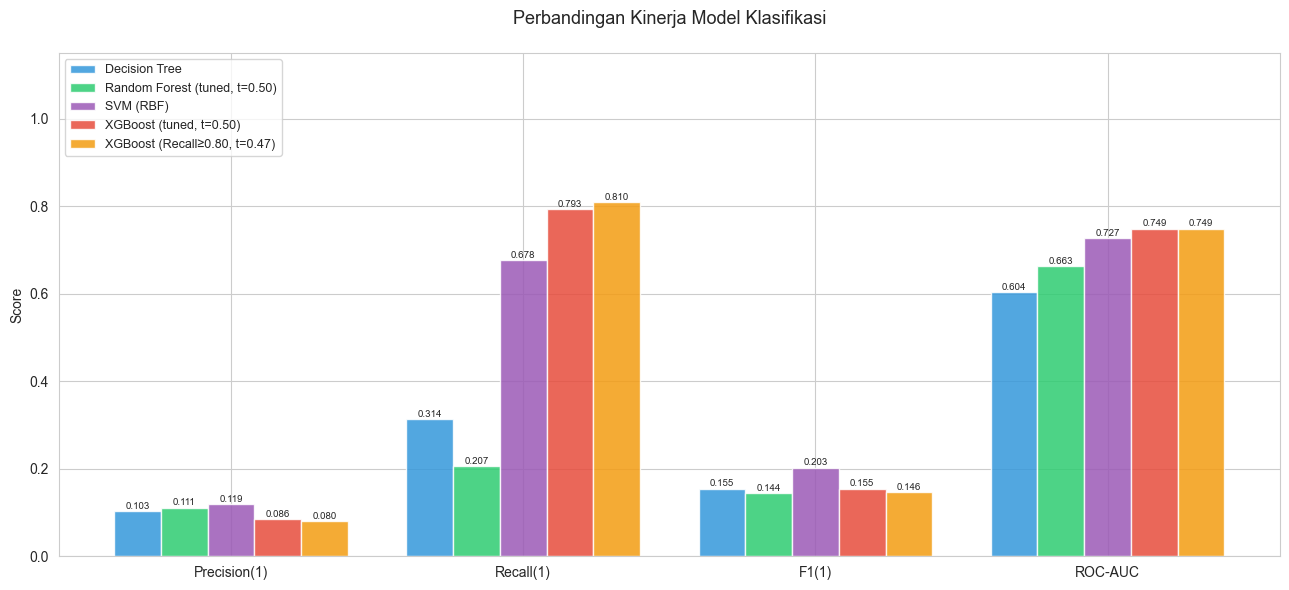

In [22]:
metrics_plot = ['Precision(1)', 'Recall(1)', 'F1(1)', 'ROC-AUC']
cmp_num = cmp_df[metrics_plot].apply(pd.to_numeric, errors='coerce')

models_key = [
    'Decision Tree',
    'Random Forest (tuned, t=0.50)',
    'SVM (RBF)',
    'XGBoost (tuned, t=0.50)',
    cmp_df['Recall(1)'].idxmax(),
]
models_key = list(dict.fromkeys(models_key))  # dedup
cmp_plot   = cmp_num.loc[[m for m in models_key if m in cmp_num.index]]

x = np.arange(len(metrics_plot))
w = 0.8 / len(cmp_plot)
colors = ['#3498DB', '#2ECC71', '#9B59B6', '#E74C3C', '#F39C12']

fig, ax = plt.subplots(figsize=(13, 6))
for i, (model, color) in enumerate(zip(cmp_plot.index, colors)):
    offset = (i - len(cmp_plot)/2 + 0.5) * w
    bars = ax.bar(x + offset, cmp_plot.loc[model], w,
                  label=model, color=color, edgecolor='white', alpha=0.85)
    for xi, val in enumerate(cmp_plot.loc[model]):
        if not np.isnan(val):
            ax.text(xi + offset, val + 0.005, f'{val:.3f}',
                    ha='center', fontsize=7)

ax.set_xticks(x); ax.set_xticklabels(metrics_plot)
ax.set_ylabel('Score'); ax.set_ylim(0, 1.15)
ax.set_title('Perbandingan Kinerja Model Klasifikasi\n')
ax.legend(loc='upper left', fontsize=9)
plt.tight_layout(); plt.show()

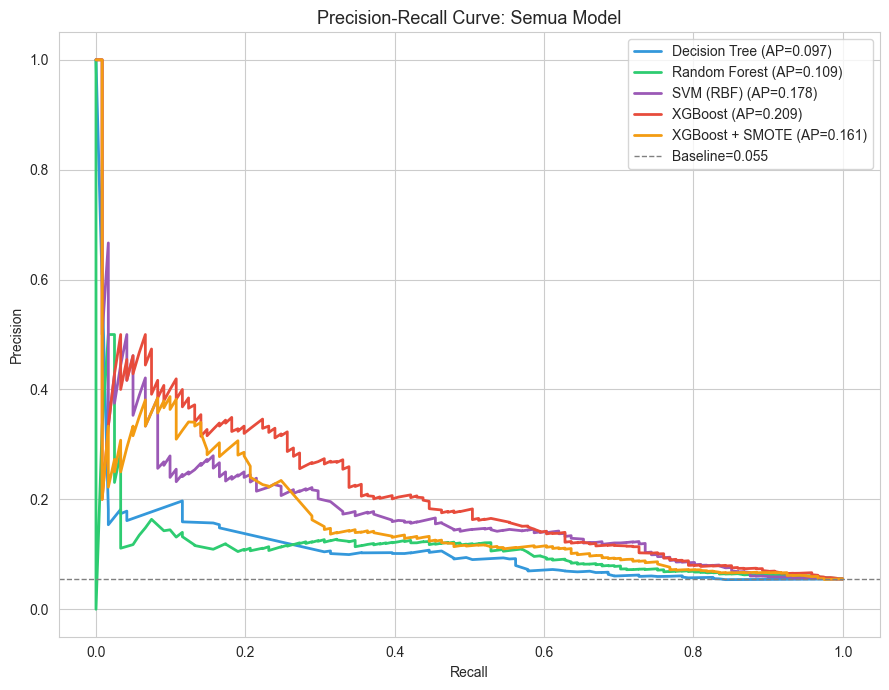

In [23]:
# Precision-Recall Curve semua model utama
fig, ax = plt.subplots(figsize=(9, 7))
for name, metrics, color in [
    ('Decision Tree',        dt_metrics,        '#3498DB'),
    ('Random Forest',        rf_metrics,        '#2ECC71'),
    ('SVM (RBF)',            svm_metrics,       '#9B59B6'),
    ('XGBoost',              xgb_metrics,       '#E74C3C'),
    ('XGBoost + SMOTE',      xgb_smote_metrics, '#F39C12'),
]:
    if metrics['y_proba'] is not None:
        prec, rec, _ = precision_recall_curve(y_test, metrics['y_proba'])
        ap = average_precision_score(y_test, metrics['y_proba'])
        ax.plot(rec, prec, lw=2, color=color, label=f'{name} (AP={ap:.3f})')

baseline = y_test.sum() / len(y_test)
ax.axhline(baseline, ls='--', color='grey', lw=1, label=f'Baseline={baseline:.3f}')
ax.set_title('Precision-Recall Curve: Semua Model')
ax.set_xlabel('Recall'); ax.set_ylabel('Precision')
ax.legend()
plt.tight_layout(); plt.show()

## Feature Importance

Menghitung permutation importance...


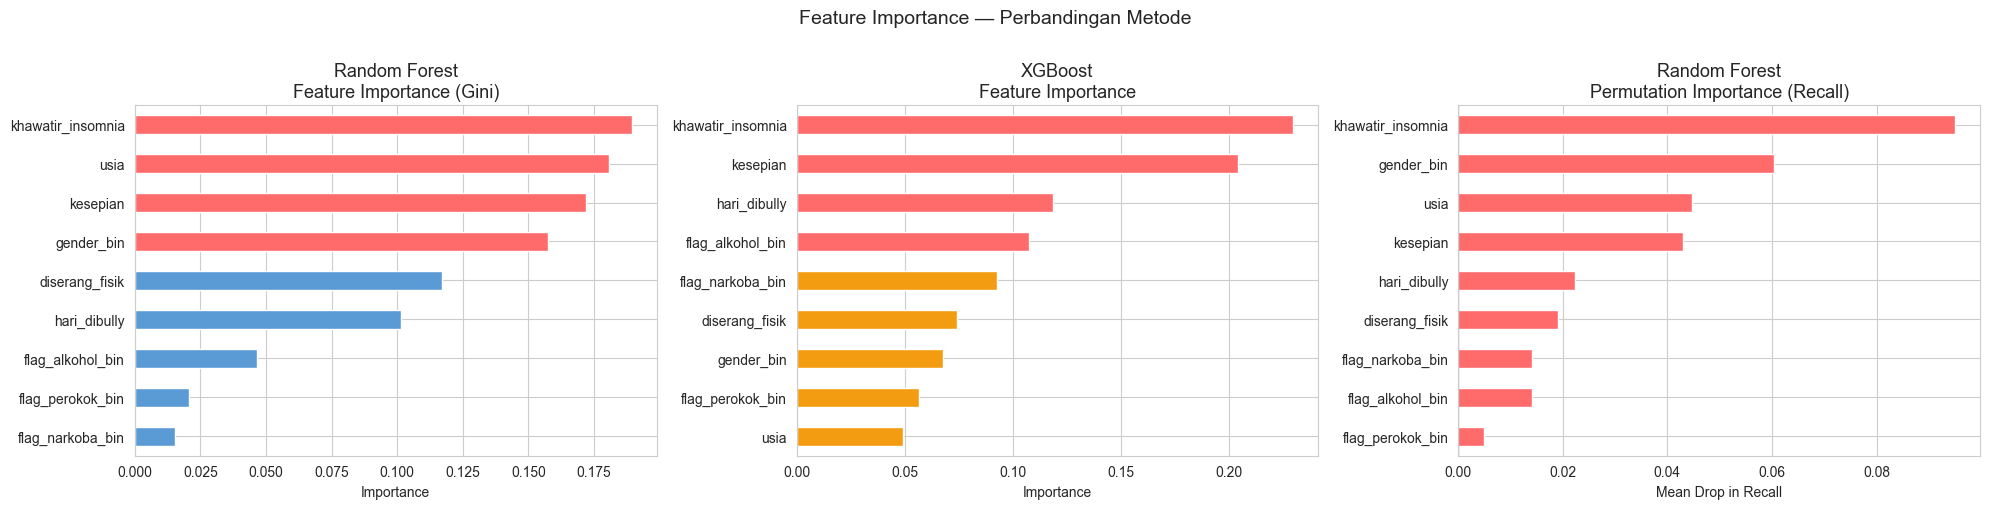


Top 5 fitur (RF Permutation Importance):
khawatir_insomnia    0.0950
gender_bin           0.0603
usia                 0.0446
kesepian             0.0430
hari_dibully         0.0223
dtype: float64

Top 5 fitur (XGBoost):
khawatir_insomnia    0.2297
kesepian             0.2042
hari_dibully         0.1183
flag_alkohol_bin     0.1074
flag_narkoba_bin     0.0925
dtype: float32


In [24]:
fig, axes = plt.subplots(1, 3, figsize=(20, max(5, len(feat_cols)*0.45)))

# RF Gini importance
fi_rf = pd.Series(rf_model.feature_importances_, index=feat_cols).sort_values()
colors_fi = ['#FF6B6B' if v > fi_rf.median() else '#5B9BD5' for v in fi_rf]
fi_rf.plot(kind='barh', ax=axes[0], color=colors_fi, edgecolor='white')
axes[0].set_title('Random Forest\nFeature Importance (Gini)')
axes[0].set_xlabel('Importance')

# XGBoost importance
fi_xgb = pd.Series(xgb_model.feature_importances_, index=feat_cols).sort_values()
colors_xgb = ['#FF6B6B' if v > fi_xgb.median() else '#F39C12' for v in fi_xgb]
fi_xgb.plot(kind='barh', ax=axes[1], color=colors_xgb, edgecolor='white')
axes[1].set_title('XGBoost\nFeature Importance')
axes[1].set_xlabel('Importance')

# Permutation importance (RF)
print('Menghitung permutation importance...')
perm = permutation_importance(rf_model, X_test, y_test,
                              scoring='recall', n_repeats=10, random_state=RS)
perm_df = pd.Series(perm.importances_mean, index=feat_cols).sort_values()
colors_p = ['#FF6B6B' if v > 0 else '#A8A8A8' for v in perm_df]
perm_df.plot(kind='barh', ax=axes[2], color=colors_p, edgecolor='white')
axes[2].axvline(0, color='black', lw=0.8)
axes[2].set_title('Random Forest\nPermutation Importance (Recall)')
axes[2].set_xlabel('Mean Drop in Recall')

plt.suptitle('Feature Importance — Perbandingan Metode', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

print('\nTop 5 fitur (RF Permutation Importance):')
print(perm_df.sort_values(ascending=False).head(5).round(4))
print('\nTop 5 fitur (XGBoost):')
print(fi_xgb.sort_values(ascending=False).head(5).round(4))

## Kesimpulan

In [25]:
best_recall_model = cmp_df['Recall(1)'].idxmax()
best_f1_model     = cmp_df['F1(1)'].idxmax()
best_row_recall   = cmp_df.loc[best_recall_model]
best_row_f1       = cmp_df.loc[best_f1_model]

print('=' * 65)
print('RINGKASAN HASIL KLASIFIKASI — VERSI IMPROVED')
print('GSHS 2015 Prediksi Suicidal Ideation')
print('=' * 65)
print(f'Dataset  : {len(df):,} pelajar, {len(feat_cols)} fitur')
print(f'Train/Test: 80% / 20% (stratified)')
print(f'Imbalance: {(y==0).sum()/(y==1).sum():.0f}:1')
print()
print('Hasil Semua Model:')
print(cmp_df.to_string())
print()
print(f'Model Recall terbaik : {best_recall_model}')
print(f'   Recall(1)={best_row_recall["Recall(1)"]}, F1={best_row_recall["F1(1)"]}, AUC={best_row_recall["ROC-AUC"]}')
print(f'\nModel F1 terbaik     : {best_f1_model}')
print(f'   Recall(1)={best_row_f1["Recall(1)"]}, F1={best_row_f1["F1(1)"]}, AUC={best_row_f1["ROC-AUC"]}')
print()
print('Top 5 Fitur Paling Berpengaruh (RF Permutation):')
for feat, val in perm_df.sort_values(ascending=False).head(5).items():
    print(f'  {feat:35s}: {val:.4f}')
print('=' * 65)

RINGKASAN HASIL KLASIFIKASI — VERSI IMPROVED
GSHS 2015 Prediksi Suicidal Ideation
Dataset  : 10,977 pelajar, 9 fitur
Train/Test: 80% / 20% (stratified)
Imbalance: 17:1

Hasil Semua Model:
                               Threshold  Accuracy  Precision(1)  Recall(1)   F1(1)  ROC-AUC
Model                                                                                       
Decision Tree                   0.500000    0.8110        0.1027     0.3140  0.1548   0.6044
Random Forest (tuned, t=0.50)   0.500000    0.8652        0.1111     0.2066  0.1445   0.6629
Random Forest (tuned, t=0.15)   0.150633    0.7609        0.1203     0.5289  0.1960   0.6629
SVM (RBF)                       0.500000    0.7063        0.1192     0.6777  0.2027   0.7271
XGBoost (tuned, t=0.50)         0.500000    0.5219        0.0856     0.7934  0.1546   0.7491
XGBoost (tuned, t=0.84)         0.839241    0.9112        0.2597     0.3306  0.2909   0.7491
XGBoost + SMOTE (t=0.50)        0.500000    0.8461        0.1395    